In [19]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt


In [20]:
df = pd.read_csv("/content/train.csv")
df.head()

,label,pixel0,pixel1,pixel2,pixel3,pixel4,pixel5,pixel6,pixel7,pixel8,...,pixel774,pixel775,pixel776,pixel777,pixel778,pixel779,pixel780,pixel781,pixel782,pixel783
0,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,1,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,4,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0


In [21]:
data = np.array(df)
m ,n = data.shape
np.random.shuffle(data)

In [22]:
train_data = data[0:int(0.8*m),:]
val_data = data[int(0.8*m):m,:]

In [23]:
type(train_data)

numpy.ndarray

In [24]:
X_train = train_data[:, 1:].T
X_train = X_train / 255.0
Y_train = train_data[:,0]
X_test = val_data[:, 1:].T
X_test = X_test / 255.0
Y_test = val_data[:,0]

In [41]:
def initialize_parameters():
    W1 = np.random.randn(128, 784) * np.sqrt(2/784)  # 10 → 128 neurons
    W2 = np.random.randn(64, 128) * np.sqrt(2/128)   # Naya layer
    W3 = np.random.randn(10, 64) * np.sqrt(2/64)     # Output layer
    B1 = np.zeros((128, 1))
    B2 = np.zeros((64, 1))
    B3 = np.zeros((10, 1))
    return W1, W2, W3, B1, B2, B3
def ReLU(Z):
    return np.maximum(Z, 0)
def softmax(Z):
    A = np.exp(Z) / sum(np.exp(Z))
    return A
def get_predictions(A3):
    return np.argmax(A3, 0)
def get_accuracy(predictions, Y):
    return np.sum(predictions == Y) / Y.size

def forward(W1, W2, W3, B1, B2, B3, X):
    Z1 = np.dot(W1, X) + B1
    A1 = ReLU(Z1)
    Z2 = np.dot(W2, A1) + B2
    A2 = ReLU(Z2)
    Z3 = np.dot(W3, A2) + B3
    A3 = softmax(Z3)
    return Z1, A1, Z2, A2, Z3, A3
def one_hot(Y):
    one_hot_Y = np.zeros((Y.size, Y.max() + 1))
    one_hot_Y[np.arange(Y.size), Y] = 1
    one_hot_Y = one_hot_Y.T
    return one_hot_Y

def backward(W1, W2, W3, B1, B2, B3, Y, X, Z1, A1, Z2, A2, Z3, A3):
    m = X.shape[1]
    one_hot_Y = one_hot(Y)
    dZ3 = A3 - one_hot_Y
    dW3 = np.dot(dZ3, A2.T) / m
    dB3 = np.sum(dZ3, axis=1, keepdims=True) / m
    dZ2 = np.dot(W3.T, dZ3) * (Z2 > 0)
    dW2 = np.dot(dZ2, A1.T) / m
    dB2 = np.sum(dZ2, axis=1, keepdims=True) / m
    dZ1 = np.dot(W2.T, dZ2) * (Z1 > 0)
    dW1 = np.dot(dZ1, X.T) / m
    dB1 = np.sum(dZ1, axis=1, keepdims=True) / m
    return dW1, dW2, dW3, dB1, dB2, dB3

def update_parameters(dW1, dW2, dW3, dB1, dB2, dB3, W1, W2, W3, B1, B2, B3, lr):
    W1 -= lr * dW1
    W2 -= lr * dW2
    W3 -= lr * dW3
    B1 -= lr * dB1
    B2 -= lr * dB2
    B3 -= lr * dB3
    return W1, W2, W3, B1, B2, B3


def gradient_decent(X, Y, learning_rate, iterations):
    W1, W2, W3, B1, B2, B3 = initialize_parameters()
    for i in range(iterations):
        Z1, A1, Z2, A2, Z3, A3 = forward(W1, W2, W3, B1, B2, B3, X)
        dW1, dW2, dW3, dB1, dB2, dB3 = backward(W1, W2, W3, B1, B2, B3, Y, X, Z1, A1, Z2, A2, Z3, A3)
        W1, W2, W3, B1, B2, B3 = update_parameters(dW1, dW2, dW3, dB1, dB2, dB3, W1, W2, W3, B1, B2, B3, learning_rate)
        if i % 20 == 0:
            print(f"Iteration {i} | Accuracy: {get_accuracy(get_predictions(A3), Y):.4f}")
    return W1, W2, W3, B1, B2, B3

W1, W2, W3, B1, B2, B3 = gradient_decent(X_train, Y_train, 0.30, 500)

Iteration 0 | Accuracy: 0.1309
Iteration 20 | Accuracy: 0.8568
Iteration 40 | Accuracy: 0.8901
Iteration 60 | Accuracy: 0.9105
Iteration 80 | Accuracy: 0.9190
Iteration 100 | Accuracy: 0.9176
Iteration 120 | Accuracy: 0.9327
Iteration 140 | Accuracy: 0.9380
Iteration 160 | Accuracy: 0.9431
Iteration 180 | Accuracy: 0.9470
Iteration 200 | Accuracy: 0.9497
Iteration 220 | Accuracy: 0.9519
Iteration 240 | Accuracy: 0.9542
Iteration 260 | Accuracy: 0.9568
Iteration 280 | Accuracy: 0.9589
Iteration 300 | Accuracy: 0.9608
Iteration 320 | Accuracy: 0.9624
Iteration 340 | Accuracy: 0.9640
Iteration 360 | Accuracy: 0.9656
Iteration 380 | Accuracy: 0.9669
Iteration 400 | Accuracy: 0.9682
Iteration 420 | Accuracy: 0.9695
Iteration 440 | Accuracy: 0.9704
Iteration 460 | Accuracy: 0.9713
Iteration 480 | Accuracy: 0.9726


Saving Screenshot 2026-05-28 014056.jpg to Screenshot 2026-05-28 014056 (2).jpg


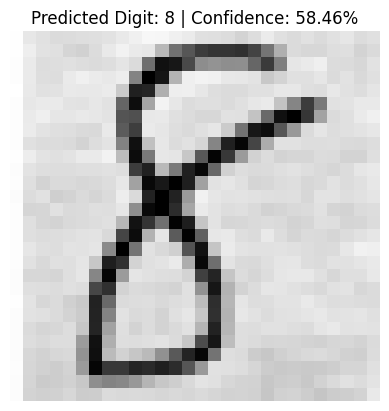

✅ Predicted Digit: 8
📊 Confidence: 58.46%

🔢 Top 3 guesses:
   Digit 8: 58.46%
   Digit 5: 23.37%
   Digit 3: 18.00%


In [40]:
from google.colab import files
from PIL import Image
import numpy as np
import matplotlib.pyplot as plt

def predict_digit(image_path, W1, W2, W3, B1, B2, B3):

    img = Image.open(image_path).convert('L')

    img = img.resize((28, 28))


    img_array = np.array(img)


    img_array = 255 - img_array


    img_array = img_array / 255.0


    img_array = img_array.reshape(784, 1)

    Z1, A1, Z2, A2, Z3, A3 = forward(W1, W2, W3, B1, B2, B3, img_array)


    prediction = get_predictions(A3)[0]
    confidence = np.max(A3) * 100


    top3 = np.argsort(A3[:, 0])[::-1][:3]


    plt.imshow(img, cmap='gray')
    plt.title(f"Predicted Digit: {prediction} | Confidence: {confidence:.2f}%")
    plt.axis('off')
    plt.show()

    print(f" Predicted Digit: {prediction}")
    print(f" Confidence: {confidence:.2f}%")
    print(f"\n Top 3 guesses:")
    for idx in top3:
        print(f"   Digit {idx}: {A3[idx, 0]*100:.2f}%")

uploaded = files.upload()
image_path = list(uploaded.keys())[0]

predict_digit(image_path, W1, W2, W3, B1, B2, B3)